In [1]:
'''In order to make the computer understand a written text, we can represent the words as numerical vectors. 
One way to do so is by Using Word embeddings, they are a way of representing words as numerical vectors. 
These vectors capture the meaning of the words and their relationships to other words in the language. 
Word embeddings can be generated using unsupervised learning algorithms such as Word2vec, GloVe, or FastText. 

Word2vec is a neural network-based method for generating word embeddings, which are dense vector 
representations of words that capture their semantic meaning and relationships. There are two main 
approaches to implementing Word2vec:

1.Continuous bag-of-words (CBOW) 
2.Skip-gram'''

'In order to make the computer understand a written text, we can represent the words as numerical vectors. \nOne way to do so is by Using Word embeddings, they are a way of representing words as numerical vectors. \nThese vectors capture the meaning of the words and their relationships to other words in the language. \nWord embeddings can be generated using unsupervised learning algorithms such as Word2vec, GloVe, or FastText. \n\nWord2vec is a neural network-based method for generating word embeddings, which are dense vector \nrepresentations of words that capture their semantic meaning and relationships. There are two main \napproaches to implementing Word2vec:\n\n1.Continuous bag-of-words (CBOW) \n2.Skip-gram'

In [2]:
'''What is a Continuous Bag of Words (CBOW)?

Continuous Bag of Words (CBOW) is a popular natural language processing technique used to generate word embeddings. 
Word embeddings are important for many NLP tasks because they capture semantic and syntactic relationships between 
words in a language. CBOW is a neural network-based algorithm that predicts a target word given its surrounding 
context words. It is a type of "unsupervised" learning, meaning that it can learn from unlabeled data, and it is 
often used to pre-train word embeddings that can be used for various NLP tasks such as sentiment analysis, text 
classification, and machine translation. '''

'What is a Continuous Bag of Words (CBOW)?\n\nContinuous Bag of Words (CBOW) is a popular natural language processing technique used to generate word embeddings. \nWord embeddings are important for many NLP tasks because they capture semantic and syntactic relationships between \nwords in a language. CBOW is a neural network-based algorithm that predicts a target word given its surrounding \ncontext words. It is a type of "unsupervised" learning, meaning that it can learn from unlabeled data, and it is \noften used to pre-train word embeddings that can be used for various NLP tasks such as sentiment analysis, text \nclassification, and machine translation. '

In [3]:
# Re-import necessary modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Lambda
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Define the corpus
corpus = [
    'The cat sat on the mat',
    'The dog ran in the park',
    'The bird sang in the tree'
]

# Convert the corpus to a sequence of integers
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)
print("After converting our words in the corpus into vector of integers:")
print(sequences)

After converting our words in the corpus into vector of integers:
[[1, 3, 4, 5, 1, 6], [1, 7, 8, 2, 1, 9], [1, 10, 11, 2, 1, 12]]


In [ ]:
'''Now, we will build the CBOW model having window size = 2.'''

# Define the parameters
vocab_size = len(tokenizer.word_index) + 1
embedding_size = 10
window_size = 2

# Generate the context-target pairs
contexts = []
targets = []
for sequence in sequences:
    for i in range(window_size, len(sequence) - window_size):
        context = sequence[i - window_size:i] + sequence[i + 1:i + window_size + 1]
        target = sequence[i]
        contexts.append(context)
        targets.append(target)

# Convert the contexts and targets to numpy arrays
X = np.array(contexts)
y = to_categorical(targets, num_classes=vocab_size)

# Define the CBOW model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=2 * window_size))
model.add(Lambda(lambda x: tf.reduce_mean(x, axis=1)))
model.add(Dense(units=vocab_size, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model

model.fit(X, y, epochs=100, verbose=0)

d:\CODING\PYTHON\PYTHON---3.11\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


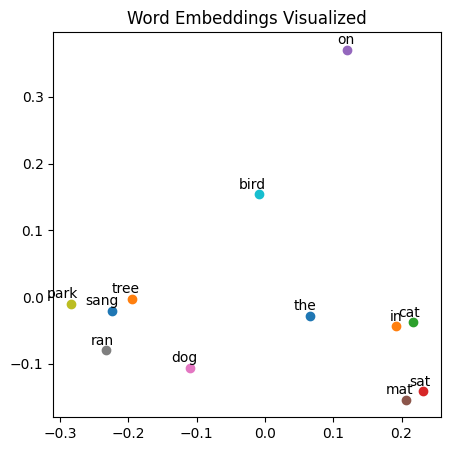

In [5]:
'''Next, we will use the model to visualize the embeddings.'''
# Extract the embeddings
embedding_layer = model.layers[0]
embeddings = embedding_layer.get_weights()[0]

# Perform PCA to reduce the dimensionality of the embeddings
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Visualize the embeddings
plt.figure(figsize=(5, 5))
for word, idx in tokenizer.word_index.items():
    x, y = reduced_embeddings[idx]
    plt.scatter(x, y)
    plt.annotate(word, xy=(x, y), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')
plt.title("Word Embeddings Visualized")
plt.show()